# Week 3b — ARIMA Demand Forecast

**Goal:** Fit a proper time-series model (**ARIMA**) per product category,
forecast the held-out 30-day test window, and save the predictions so we can
compare them against the moving-average baseline next.

> ARIMA(1,1,1) is a sensible default. If a category fails to converge, we fall
> back to the flat moving-average so every category still gets a forecast.


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

DAILY_PATH = Path('..') / 'data' / 'processed' / 'supply_chain_daily.csv'
OUT_PATH = Path('..') / 'data' / 'processed' / 'arima_forecast.csv'
TARGET = 'units_sold'
HORIZON = 30            # days held out for testing
WINDOW = 7              # fallback moving-average window
ORDER = (1, 1, 1)       # ARIMA (p, d, q)
SAMPLE_CAT = 'Electronics'

daily = pd.read_csv(DAILY_PATH, parse_dates=['date'])
daily = daily.sort_values(['product_category', 'date']).reset_index(drop=True)
print('Loaded shape:', daily.shape)
print('Date range:', daily['date'].min().date(), '->', daily['date'].max().date())

Loaded shape: (12200, 7)
Date range: 2020-01-01 -> 2023-04-01


## 1. Train / test split

Same split as the baseline: hold out the last 30 days of every category so the
two models are judged on identical test windows.

In [2]:
def train_test_split(frame, horizon=HORIZON):
    train_parts, test_parts = [], []
    for cat, sub in frame.groupby('product_category'):
        sub = sub.sort_values('date')
        train_parts.append(sub.iloc[:-horizon])
        test_parts.append(sub.iloc[-horizon:])
    return pd.concat(train_parts, ignore_index=True), pd.concat(test_parts, ignore_index=True)

train, test = train_test_split(daily)
print('Train rows:', len(train), '| Test rows:', len(test))

Train rows: 11870 | Test rows: 330


## 2. Fit ARIMA per category

For each category we fit ARIMA on the training demand series and forecast the
next 30 days. A `try/except` guard keeps one stubborn category from breaking
the run.

In [3]:
def arima_forecast(train_frame, test_frame, order=ORDER, horizon=HORIZON, window=WINDOW):
    parts = []
    for cat, sub in test_frame.groupby('product_category'):
        sub = sub.sort_values('date').copy()
        series = (train_frame[train_frame['product_category'] == cat]
                  .sort_values('date')[TARGET].astype(float).reset_index(drop=True))
        try:
            fitted = ARIMA(series, order=order).fit()
            forecast = np.asarray(fitted.forecast(steps=horizon), dtype=float)
            model_used = f'ARIMA{order}'
        except Exception:
            forecast = np.repeat(series.tail(window).mean(), horizon)
            model_used = 'fallback_ma'
        sub['forecast_arima'] = np.round(forecast, 2)
        sub['model_used'] = model_used
        parts.append(sub[['date', 'product_category', TARGET, 'forecast_arima', 'model_used']])
    return pd.concat(parts, ignore_index=True)

arima = arima_forecast(train, test)
print('ARIMA forecast rows:', len(arima))
print('Models used:')
print(arima.groupby('product_category')['model_used'].first())
arima.head()

ARIMA forecast rows: 330
Models used:
product_category
Apparel             ARIMA(1, 1, 1)
Automotive Parts    ARIMA(1, 1, 1)
Beauty              ARIMA(1, 1, 1)
Clothing            ARIMA(1, 1, 1)
Electronics         ARIMA(1, 1, 1)
Furniture           ARIMA(1, 1, 1)
Groceries           ARIMA(1, 1, 1)
Office Supplies     ARIMA(1, 1, 1)
Pet Supplies        ARIMA(1, 1, 1)
Sporting Goods      ARIMA(1, 1, 1)
Toys                ARIMA(1, 1, 1)
Name: model_used, dtype: str


,date,product_category,units_sold,forecast_arima,model_used
0,2022-12-06,Apparel,520.70,549.79,"ARIMA(1, 1, 1)"
1,2022-12-07,Apparel,536.50,564.09,"ARIMA(1, 1, 1)"
2,2022-12-08,Apparel,495.45,568.65,"ARIMA(1, 1, 1)"
3,2022-12-09,Apparel,454.40,570.10,"ARIMA(1, 1, 1)"
4,2022-12-10,Apparel,479.85,570.56,"ARIMA(1, 1, 1)"


## 3. Save the forecasts

In [4]:
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
arima.to_csv(OUT_PATH, index=False)
print('Saved', len(arima), 'rows to', OUT_PATH)

Saved 330 rows to ../data/processed/arima_forecast.csv


## 4. Visualize ARIMA vs actual

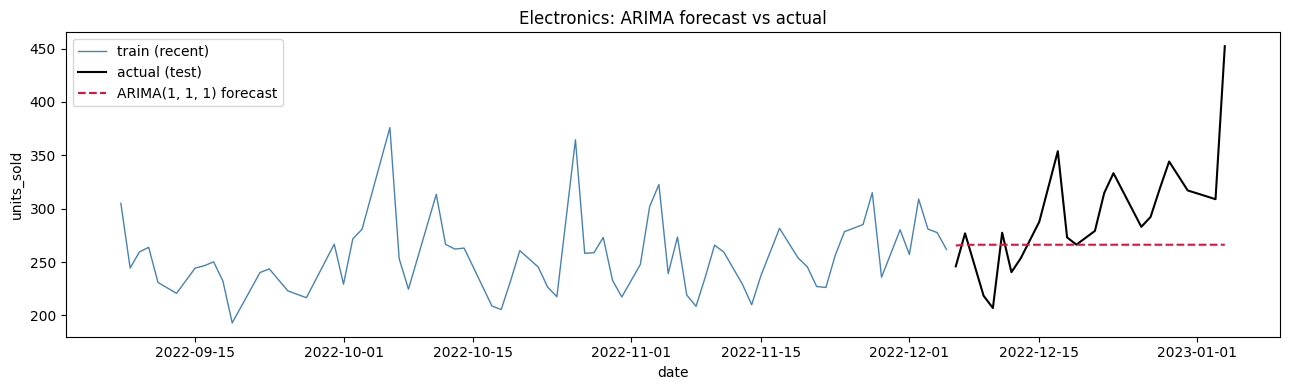

In [5]:
hist = train[train['product_category'] == SAMPLE_CAT].sort_values('date').tail(90)
fc = arima[arima['product_category'] == SAMPLE_CAT].sort_values('date')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(hist['date'], hist[TARGET], color='steelblue', lw=1, label='train (recent)')
ax.plot(fc['date'], fc[TARGET], color='black', lw=1.5, label='actual (test)')
ax.plot(fc['date'], fc['forecast_arima'], color='crimson', lw=1.5, ls='--',
        label=f'ARIMA{ORDER} forecast')
ax.set_title(f'{SAMPLE_CAT}: ARIMA forecast vs actual')
ax.set_xlabel('date'); ax.set_ylabel(TARGET); ax.legend()
plt.tight_layout()
plt.show()